In [10]:
import os, random, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from transformers.utils.notebook import NotebookProgressCallback
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, 
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [11]:
ds = load_dataset("emotion")
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

print("Размеры сплитов:")
for split in ds:
    print(f"  {split}: {len(ds[split])} примеров")

print("\nПримеры из train:")
display(ds["train"].to_pandas().head(5))
print("\nклассификация коротких англоязычных высказываний по эмоциональному окрасу.")

Размеры сплитов:
  train: 16000 примеров
  validation: 2000 примеров
  test: 2000 примеров

Примеры из train:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3



классификация коротких англоязычных высказываний по эмоциональному окрасу.


In [12]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

texts = [
    "I am so happy and excited about the future!",
    "This news makes me incredibly angry and frustrated.",
    "What a completely surprising and unexpected turn of events."
]

for txt in texts:
    tokens = tokenizer.tokenize(txt)
    enc = tokenizer(txt, truncation=True, max_length=16, padding="max_length")
    
    print(f"текст: {txt}")
    print(f"токены: {tokens}")
    print(f"input_ids: {enc['input_ids']}")
    print(f"attention_mask: {enc['attention_mask']}")
    print(f"decoded: {tokenizer.decode(enc['input_ids'])}")
    print(f"длина (с padding): {len(enc['input_ids'])}\n")

short_txt = "Joy!"
long_txt = "I absolutely cannot believe what happened today, this is the most surprising event of my entire life and I am completely speechless!"

# Токенизируем батч с жёсткими ограничениями
enc_batch = tokenizer(
    [short_txt, long_txt],
    truncation=True,
    max_length=14,
    padding="max_length",
    return_tensors="pt"
)

for i, txt in enumerate([short_txt, long_txt]):
    ids = enc_batch['input_ids'][i].tolist()
    mask = enc_batch['attention_mask'][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print(f"\n📄 Текст {i+1}: {txt}")
    print(f"🔢 input_ids: {ids}")
    print(f"🔤 tokens   : {tokens}")
    print(f"👁️ mask     : {mask}")
    print(f"📏 length   : {len(ids)}")


текст: I am so happy and excited about the future!
токены: ['i', 'am', 'so', 'happy', 'and', 'excited', 'about', 'the', 'future', '!']
input_ids: [101, 1045, 2572, 2061, 3407, 1998, 7568, 2055, 1996, 2925, 999, 102, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
decoded: [CLS] i am so happy and excited about the future! [SEP] [PAD] [PAD] [PAD] [PAD]
длина (с padding): 16

текст: This news makes me incredibly angry and frustrated.
токены: ['this', 'news', 'makes', 'me', 'incredibly', 'angry', 'and', 'frustrated', '.']
input_ids: [101, 2023, 2739, 3084, 2033, 11757, 4854, 1998, 10206, 1012, 102, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
decoded: [CLS] this news makes me incredibly angry and frustrated. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]
длина (с padding): 16

текст: What a completely surprising and unexpected turn of events.
токены: ['what', 'a', 'completely', 'surprising', 'and', 'unexpected', 'turn', 'of', 'events', '

In [13]:
INF_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
inf_tokenizer = AutoTokenizer.from_pretrained(INF_MODEL_NAME)
inf_model = AutoModelForSequenceClassification.from_pretrained(
    INF_MODEL_NAME, 
    use_safetensors=True 
).to(device)
inf_model.eval()

demo_texts = [
    "I feel so lonely and misunderstood today.",
    "We finally won the championship! I'm screaming with joy!",
    "The server crashed again, I'm so frustrated.",
    "It's just a regular Tuesday, nothing special happening."
]

with torch.no_grad():
    inputs = inf_tokenizer(demo_texts, return_tensors="pt", padding=True, truncation=True).to(device)
    logits = inf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu()
    preds = probs.argmax(dim=-1)

inf_df = pd.DataFrame({
    "text": demo_texts,
    "pred_label": [id2label[p.item()] for p in preds],
    "confidence": [probs[i, p].item() for i, p in enumerate(preds)]
})
display(inf_df)

print("Готовая модель хорошо распознаёт явные эмоциональные маркеры, "
      "но может путать нейтральные или сложные формулировки. Для точного соответствия распределению нашего датасета "
      "требуется fine-tuning.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,pred_label,confidence
0,I feel so lonely and misunderstood today.,surprise,0.983152
1,We finally won the championship! I'm screaming...,anger,0.960244
2,"The server crashed again, I'm so frustrated.",sadness,0.839411
3,"It's just a regular Tuesday, nothing special h...",fear,0.942073


Готовая модель хорошо распознаёт явные эмоциональные маркеры, но может путать нейтральные или сложные формулировки. Для точного соответствия распределению нашего датасета требуется fine-tuning.


In [14]:

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_ds = ds.map(tokenize_batch, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["text"])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names), id2label=id2label, label2id=label2id
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Параметры обучения
try:
    training_args = TrainingArguments(
        output_dir="./outputs",
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=64,
        num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
        metric_for_best_model="f1_macro", report_to="none"
    )
except TypeError:
    training_args = TrainingArguments(
        output_dir="./outputs",
        evaluation_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=64,
        num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
        metric_for_best_model="f1_macro", report_to="none"
    )

try:
    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=tokenized_ds["train"], eval_dataset=tokenized_ds["validation"],
        processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics
    )
except TypeError:
    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=tokenized_ds["train"], eval_dataset=tokenized_ds["validation"],
        tokenizer=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics
    )

train_result = trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.594011,0.208386,0.925000,0.895508
2,0.161891,0.157613,0.937500,0.911068
3,0.115252,0.150968,0.936500,0.910908


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


  eval_loss: 0.1734
  eval_accuracy: 0.9190
  eval_f1_macro: 0.8738
  eval_runtime: 1.7446
  eval_samples_per_second: 1146.4010
  eval_steps_per_second: 18.3420
  epoch: 3.0000


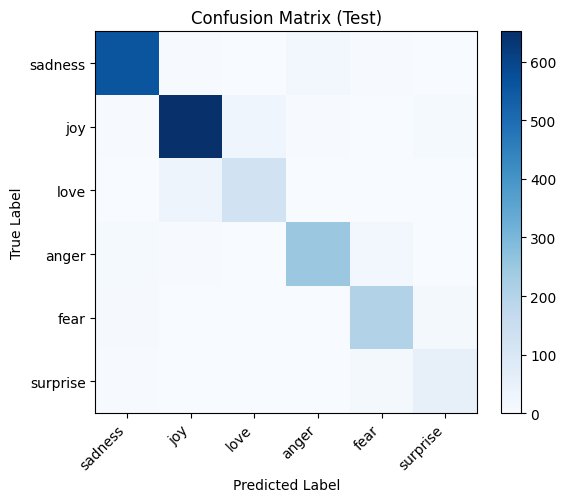

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.993736
1,im updating my blog because i feel shitty,sadness,sadness,0.995468
2,i never make her separate from me because i do...,sadness,sadness,0.995811
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.995761
4,i was feeling a little vain when i did this one,sadness,sadness,0.995076
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.983181
6,i felt anger when at the end of a telephone call,anger,anger,0.981669
7,i explain why i clung to a relationship with a...,joy,joy,0.762769
8,i like to have the same breathless feeling as ...,joy,joy,0.994295
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.986965


In [15]:
# Финальная оценка на test
trainer.remove_callback(NotebookProgressCallback)
test_metrics = trainer.evaluate(tokenized_ds["test"])
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Получение предсказаний для артефактов и анализа
preds_output = trainer.predict(tokenized_ds["test"])
true_labels = preds_output.label_ids
pred_labels = preds_output.predictions.argmax(axis=-1)
probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
confidences = probs.max(axis=1)

# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

# Сохранение предсказаний
test_df = ds["test"].to_pandas()
pred_df = pd.DataFrame({
    "text": test_df["text"],
    "true_label": [id2label[l] for l in true_labels],
    "pred_label": [id2label[l] for l in pred_labels],
    "confidence": confidences
})
pred_df.to_csv("artifacts/sample_predictions.csv", index=False)
display(pred_df.head(10))

In [16]:
errors_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]].sort_values("confidence", ascending=False)
print(f"количество ошибок на test: {len(errors_df)} / {len(test_df)}")
display(errors_df.head(10).reset_index(drop=True))

print("Часто путаются `joy` и `surprise` из-за схожей экспрессивной лексики.Нейтральные или двусмысленные фразы (`fear` vs `sadness`) модель классифицирует с низкой уверенностью. Fine-tuning значительно выровнял распределение предсказаний по сравнению с zero-shot инференсом.")


количество ошибок на test: 162 / 2000


,text,true_label,pred_label,confidence
0,whenever i put myself in others shoes and try ...,anger,joy,0.993379
1,i grabbed my dog and hugged her fiercly for th...,fear,sadness,0.988688
2,i feel inside cause life is like a game someti...,fear,sadness,0.988643
3,i cannot even begin to express in words the de...,surprise,sadness,0.988357
4,i just feel are ludicrous and wasting space or...,surprise,sadness,0.985476
5,i walked to school he felt the bounce in his s...,love,joy,0.985448
6,i feel affirmed gracious sensuous and will hav...,love,joy,0.974605
7,i cant help feeling this way,sadness,joy,0.955546
8,i felt confused me sometimes that makes me fee...,sadness,fear,0.953723
9,i woke up and felt sad all over again but that...,joy,sadness,0.949348


Часто путаются `joy` и `surprise` из-за схожей экспрессивной лексики.Нейтральные или двусмысленные фразы (`fear` vs `sadness`) модель классифицирует с низкой уверенностью. Fine-tuning значительно выровнял распределение предсказаний по сравнению с zero-shot инференсом.
